==============================================================================
ASSIGNMENT 1: STUDENT STARTER NOTEBOOK
Course: Data Mining (Undergrad High-Level Summer Online Course)
Topics: Linear & Logistic Regression, Class Imbalance Handling
==============================================================================

In [1]:
# ------------------------------------------------------------------------------
# 0. Environment Setup & Library Imports
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning Processing & Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
# Evaluation Metrics
from sklearn.metrics import (
    mean_squared_error, 
    r2_score, 
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_curve, 
    auc
)
# Imbalance Treatment
# NOTE: If not installed, run 'pip install imbalanced-learn' in your terminal
from imblearn.over_sampling import SMOTE
# Plotting Settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 7)
print("Packages loaded. Ready to begin.")

Packages loaded. Ready to begin.


In [2]:
# ------------------------------------------------------------------------------
# 1. Dataset Generation (Synthetic Mocking Environment)
# ------------------------------------------------------------------------------
# Set seed for reproducibility. Do not change this.
np.random.seed(42)
# --- 1A. Generate Bike Sharing Regression Dataset ---
n_samples_bike = 500
bike_data = {
    'temp': np.random.uniform(0.1, 0.9, n_samples_bike),
    'hum': np.random.uniform(0.3, 0.8, n_samples_bike),
    'windspeed': np.random.uniform(0.05, 0.5, n_samples_bike),
    'season': np.random.choice(['spring', 'summer', 'fall', 'winter'], n_samples_bike),
    'holiday': np.random.choice([0, 1], n_samples_bike, p=[0.95, 0.05])
}
df_bike = pd.DataFrame(bike_data)
df_bike['cnt'] = (1500 + (3500 * df_bike['temp']) - (800 * df_bike['hum']) - 
                  (500 * df_bike['windspeed']) + np.random.normal(0, 150, n_samples_bike)).astype(int)
# --- 1B. Generate Heart Disease Classification Dataset ---
n_samples_heart = 600
heart_data = {
    'age': np.random.randint(29, 78, n_samples_heart),
    'chol': np.random.randint(126, 564, n_samples_heart),
    'thalach': np.random.randint(71, 202, n_samples_heart),
    'sex': np.random.choice([0, 1], n_samples_heart, p=[0.3, 0.7]),
    'cp': np.random.choice([0, 1, 2, 3], n_samples_heart)
}
df_heart = pd.DataFrame(heart_data)
log_odds = -5 + (0.04 * df_heart['age']) - (0.03 * df_heart['thalach']) + (1.2 * df_heart['sex'])
prob = 1 / (1 + np.exp(-log_odds))
df_heart['target'] = np.where(prob > np.percentile(prob, 85), 1, 0)
print(f"Loaded df_bike Shape: {df_bike.shape}")
print(f"Loaded df_heart Shape: {df_heart.shape}")
# ==============================================================================
# TASK 1: EXPLORATORY DATA ANALYSIS & PREPROCESSING
# ==============================================================================
print("\n--- Running Task 1 ---")
# 1.1 One-Hot Encode Categorical Columns using pd.get_dummies()
# Hint: Encode 'season' for df_bike and 'cp' for df_heart. Use drop_first=True.
# TODO: Your code here
df_bike_encoded = pd.get_dummies(df_bike, columns=['season'], drop_first=True)
df_heart_encoded = pd.get_dummies(df_heart, columns=['cp'], drop_first=True)
# 1.2 Separate Features (X) and Target (y) variables
# TODO: Your code here
X_bike = df_bike_encoded.drop(columns='cnt')
y_bike = df_bike_encoded['cnt']
X_heart = df_heart_encoded.drop(columns='target')
y_heart = df_heart_encoded['target']
# 1.3 Split both datasets into 80% training and 20% testing sets
# Hint: Use train_test_split, set random_state=42. Stratify the heart dataset target.
# TODO: Your code here
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bike, y_bike, train_size=0.8, test_size=0.2, random_state=42)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_heart, y_heart, train_size=0.8, test_size=0.2, random_state=42, stratify=y_heart)
# 1.4 Standardize continuous features using StandardScaler
# Hint: Fit and transform on train data; transform ONLY on test data.
# TODO: Your code here
scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)
scaler_h = StandardScaler()
X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_test_h_scaled = scaler_h.transform(X_test_h)

Loaded df_bike Shape: (500, 6)
Loaded df_heart Shape: (600, 6)

--- Running Task 1 ---


In [3]:
# ==============================================================================
# TASK 2: MULTIPLE LINEAR REGRESSION MODEL
# ==============================================================================
print("\n--- Running Task 2 ---")
# 2.1 Initialize and fit the Multiple Linear Regression model
# TODO: Your code here
lin_reg = LinearRegression().fit(X_train_b_scaled, y_train_b)
# 2.2 Print out the model intercept and feature coefficients
# TODO: Your code here
print("Intercepts: ", lin_reg.intercept_)
# prints '[feature]: coefficient' from linear reg model
print("Coefficients:")
for feature, coefficient in zip(X_bike.columns, lin_reg.coef_):
    print(feature, ":", coefficient)
# 2.3 Generate predictions on the scaled test set
# TODO: Your code here
y_pred_b = lin_reg.predict(X_test_b_scaled)
# 2.4 Compute and print regression metrics: MSE, RMSE, and R2 Score
# TODO: Your code here
mse_b = mean_squared_error(y_test_b, y_pred_b)
rmse_b = np.sqrt(mse_b)
r2_b = r2_score(y_test_b, y_pred_b)
print("MSE: ", mse_b)
print("RMSE: ", rmse_b)
print("R2 score: ", r2_b)


--- Running Task 2 ---
Intercepts:  2684.55
Coefficients:
temp : 847.8869771542855
hum : -114.18085677111598
windspeed : -63.44922883028593
holiday : -7.088321057162145
season_spring : 2.879825844394375
season_summer : -6.530080198456233
season_winter : -8.710904508355682
MSE:  23902.924155976227
RMSE:  154.60570544445062
R2 score:  0.9666534027489804


In [4]:
# ==============================================================================
# TASK 3: LOGISTIC REGRESSION MODEL & CLASS IMBALANCE MITIGATION
# ==============================================================================
print("\n--- Running Task 3 ---")
# 3.1 Print the percentage distribution of the target variable in y_train_h
# TODO: Your code here
targetperc = y_train_h.value_counts(normalize = True) * 100
print("Percent distribution of target variable (heart): \n", targetperc)
# 3.2 Initialize SMOTE and resample the scaled training classification data
# Hint: Use the fit_resample method on X_train_h_scaled and y_train_h with random_state=42.
# TODO: Your code here
smote = SMOTE(random_state=42)
X_train_h_smote, y_train_h_smote = smote.fit_resample(X_train_h_scaled, y_train_h)
# 3.3 Set up three variants of the Logistic Regression model
# Variant 1: Baseline model (default settings)
# Variant 2: Algorithm-level balance (set class_weight='balanced')
# Variant 3: Data-level balance (trained on SMOTE resampled data)
# Hint: Remember to use random_state=42 for all initializations.
# TODO: Your code here
models_logistic = {
    'Baseline': LogisticRegression(random_state=42),
    'Balanced_Weights': LogisticRegression(random_state=42, class_weight='balanced'),
    'SMOTE_Resampled': LogisticRegression(random_state=42)
}
# 3.4 Train the models, generate predictions, and extract performance metrics
# Create storage structures for mapping evaluation metrics
metrics_summary = {}
roc_plotting_data = {}
for name, model in models_logistic.items():
    # TODO: Fit the model on the correct training data variation
    # Fits model on resampled if model name is 'SMOTE_Resampled', else train on scaled
    if name == 'SMOTE_Resampled':
        model.fit(X_train_h_smote, y_train_h_smote)
    else:
        model.fit(X_train_h_scaled, y_train_h)
    # TODO: Generate class predictions on the original unmutated test set (X_test_h_scaled)
    preds = model.predict(X_test_h_scaled)
    
    # TODO: Generate predicted probabilities using predict_proba() for the positive class (column 1)
    probs = model.predict_proba(X_test_h_scaled)[:, 1]
    
    # TODO: Compute and store classification metrics (Accuracy, Precision, Recall, F1, Confusion Matrix)
    # Complete the dictionary entry below
    metrics_summary[name] = {
        'Accuracy': accuracy_score(y_test_h, preds),
        'Precision': precision_score(y_test_h, preds),
        'Recall': recall_score(y_test_h, preds),
        'F1_Score': f1_score(y_test_h, preds),
        'Conf_Matrix': confusion_matrix(y_test_h, preds)
    }
    # TODO: Compute roc_curve and auc values, then save them into roc_plotting_data
    fpr, tpr, thresholds = roc_curve(y_test_h, probs)
    roc_auc = auc(fpr, tpr)
    roc_plotting_data[name] = (fpr, tpr, roc_auc)
# 3.5 Print out your metrics summary block for all three configurations
# TODO: Your code here
for name, metrics in metrics_summary.items():
    print(f"\n{name}")
    print("Accuracy: ", metrics['Accuracy'])
    print("Precision: ", metrics['Precision'])
    print("Recall: ", metrics['Recall'])
    print("F1 Score: ", metrics['F1_Score'])
    print("Confusion Matrix: \n", metrics['Conf_Matrix'])


--- Running Task 3 ---
Percent distribution of target variable (heart): 
 target
0    85.0
1    15.0
Name: proportion, dtype: float64

Baseline
Accuracy:  0.9916666666666667
Precision:  0.9473684210526315
Recall:  1.0
F1 Score:  0.972972972972973
Confusion Matrix: 
 [[101   1]
 [  0  18]]

Balanced_Weights
Accuracy:  0.9583333333333334
Precision:  0.782608695652174
Recall:  1.0
F1 Score:  0.8780487804878049
Confusion Matrix: 
 [[97  5]
 [ 0 18]]

SMOTE_Resampled
Accuracy:  0.975
Precision:  0.8571428571428571
Recall:  1.0
F1 Score:  0.9230769230769231
Confusion Matrix: 
 [[99  3]
 [ 0 18]]



--- Running Task 4 ---


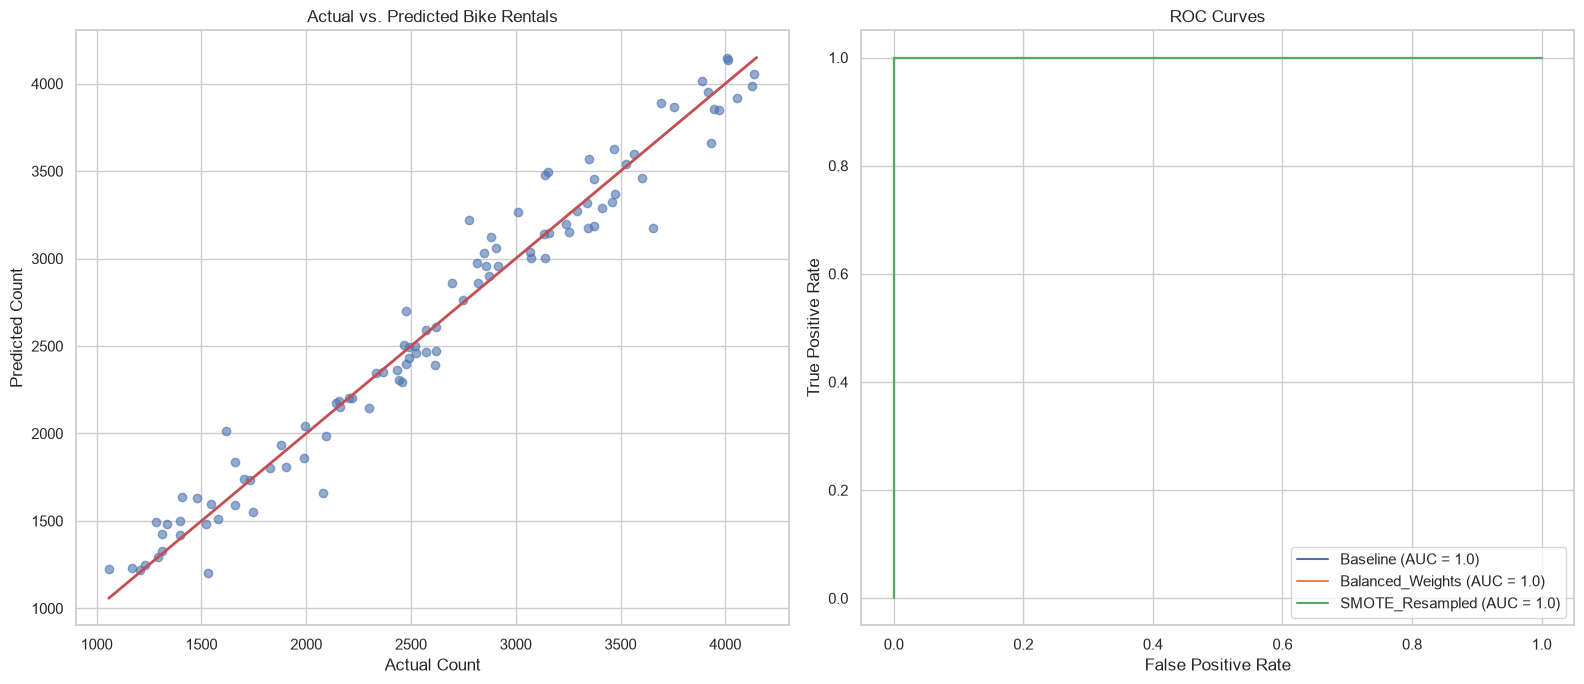

In [5]:
# ==============================================================================
# TASK 4: VISUALIZATION
# ==============================================================================
print("\n--- Running Task 4 ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# 4.1 Subplot 1: Create a scatter plot of Actual vs. Predicted values for Linear Regression
# Hint: Draw a diagonal line indicating perfect prediction accuracy.
# TODO: Your code here
# Creates scatter plot
plt.subplot(1, 2, 1)
plt.scatter(y_test_b, y_pred_b, alpha=0.6)
# Perfect prediction diagonal line
min_val = min(y_test_b.min(), y_pred_b.min())
max_val = max(y_test_b.max(), y_pred_b.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r-', linewidth=2)
# Labels
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs. Predicted Bike Rentals")
# 4.2 Subplot 2: Plot and overlay ROC curves for Baseline, Balanced, and SMOTE models
# Hint: Iterate through roc_plotting_data to label curves and include the calculated AUC score.
# TODO: Your code here
plt.subplot(1,2,2)
# iterates through roc_plotting_data
for model in roc_plotting_data:
    fpr, tpr, roc_auc = roc_plotting_data[model]
    plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc})')
# Labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.show()